# 공공데이터를 활용한 미세먼지 농도 예측 프로젝트
## 단계2. 모델링(머신러닝)

## 0.프로젝트 소개

### (1) 수행 목표
- 미세먼지 농도를 예측하는 머신러닝 모델을 만드세요.

#### 우리가 풀어야 하는 문제는 무엇인가요?
* 서울 지역의 미세먼지 데이터와 날씨 데이터를 활용하여,
미세먼지 예측에 관련 있는 데이터 항목으로 데이터를 구성, 전처리 하여
미세먼지 농도를 예측하는 머신러닝 모델 구현


### (2) 데이터 소개

#### 1) 기본 데이터

* 학습 데이터
    * air_2021.csv : 2021년 미세먼지 데이터
    * weather_2021.csv : 2021년 날씨 데이터
* 테스트 데이터
    * air_2022.csv : 2022년 미세먼지 데이터
    * weather_2022.csv : 2022년 날씨 데이터

#### 2) 데이터셋의 변수 소개(weather_2021)

* 증기압: 증기가 고체 또는 액체와 동적 평형 상태에 있을 때 증기의 압력 (증기가 되려는 힘)
* 이슬점 온도: 불포화 상태의 공기가 냉각될 때, 포화 상태에 도달하여 수증기의 응결이 시작되는 온도
* 일조: 일정한 물체나 땅의 겉면에 태양 광선이 비치는 시간 (1시간 중 비율)
* 일사(량): 태양으로부터 오는 태양 복사 에너지가 지표에 닿는 양 (면적당 에너지 량)
* 전운량: 하늘을 육안으로 관측하여 전부 구름일 때 10, 구름이 덮고 있는 하늘의 비율에 따라 0~10
* 중하층운량: 중층과 하층에 있는 구름의 분포량(중하층 구름이 날씨에 영향 주므로 따로 표기)
* 운형(운형약어): 구름의 종류. 약어 코드로 기재됨
* 최저운고: 가장 낮은 구름의 높이
* 현상번호(국내식): 비, 소낙비, 싸락눈, 눈보라 등의 기상현상을 나타낸 코드번호
* 지면온도: 지면 0cm 온도
* 지중온도: 땅 속 온도변수1

#### 2) 라이브러리 로딩

In [ ]:
!pip install catboost
!pip install pmdarima
!pip install pycaret
!pip install matplotlib=3.7.2

In [ ]:
# 필요한 라이브러리 설치 및 임포트

import pandas as pd
import torch
import numpy as np
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from pycaret.regression import *
from sklearn.ensemble import StackingRegressor

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score as acc
from sklearn.metrics import recall_score as recall
import joblib

# [Step 3] 머신러닝 모델링


In [2]:
!where python

/opt/anaconda3/bin/python


In [9]:
# 필요한 라이브러리 설치 및 임포트

import pandas as pd
import numpy as np
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import StackingRegressor

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_error 
from sklearn.metrics import r2_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score as acc
from sklearn.metrics import recall_score as recall
import joblib

#### **<span style="color:blue">[3-1] 학습 및 테스트 데이터 로딩</span>**

In [11]:
# train_x.csv / train_y.csv / test_x.csv / test_y.csv 4개의 데이터 로딩
train_x = pd.read_csv('train_x1.csv')
train_y = pd.read_csv('train_y1.csv')

test_x = pd.read_csv('test_x1.csv')
test_y = pd.read_csv('test_y1.csv')

In [13]:
train_x.describe()

,Unnamed: 0,측정일시,SO2,CO,O3,NO2,PM25,기온(°C),강수량(mm),풍속(m/s),...,시정(10m),지면온도(°C),5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C),month,day,hour,PM10_lag1
count,8734.000000,8.734000e+03,8734.000000,8734.000000,8734.000000,8734.000000,8734.000000,8734.000000,8734.000000,8734.000000,...,8734.000000,8734.000000,8734.000000,8734.000000,8734.000000,8734.000000,8734.000000,8734.000000,8734.000000,8734.000000
mean,4391.249943,2.021067e+09,0.003382,0.505078,0.029316,0.023280,20.398557,13.717861,0.134394,2.311612,...,1719.073964,14.716258,15.112228,14.538299,14.516178,14.810121,6.516831,15.761049,11.500000,38.840394
std,2521.757803,3.450285e+04,0.000826,0.209218,0.019671,0.014446,16.531826,10.901469,1.177849,1.120995,...,521.692003,12.045798,10.181298,10.049658,9.743827,9.364025,3.447750,8.773133,6.921188,47.304745
min,24.000000,2.021010e+09,0.001000,0.200000,0.000000,0.003000,1.000000,-18.500000,0.000000,0.000000,...,33.000000,-12.700000,-4.700000,-4.600000,-3.000000,-0.800000,1.000000,1.000000,0.000000,3.000000
25%,2207.500000,2.021040e+09,0.003000,0.400000,0.015000,0.012000,10.000000,6.000000,0.000000,1.500000,...,1715.250000,4.300000,5.900000,5.500000,5.600000,6.200000,4.000000,8.000000,6.000000,18.000000
50%,4391.500000,2.021070e+09,0.003000,0.400000,0.028000,0.019000,16.000000,14.500000,0.000000,2.200000,...,2000.000000,15.400000,15.400000,14.700000,14.600000,15.100000,7.000000,16.000000,11.500000,30.000000
75%,6574.750000,2.021098e+09,0.004000,0.600000,0.040000,0.031000,25.000000,22.600000,0.000000,2.900000,...,2000.000000,23.600000,24.100000,23.500000,23.400000,23.600000,9.750000,23.000000,17.000000,46.000000
max,8758.000000,2.021123e+09,0.011000,2.000000,0.137000,0.082000,154.000000,36.300000,64.700000,8.300000,...,2000.000000,56.800000,35.700000,33.700000,31.900000,30.600000,12.000000,31.000000,23.000000,942.000000


In [15]:
train_x.head()

,Unnamed: 0,측정일시,SO2,CO,O3,NO2,PM25,일시,기온(°C),강수량(mm),...,시정(10m),지면온도(°C),5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C),month,day,hour,PM10_lag1
0,24,2021100201,0.002,0.3,0.046,0.012,7.0,2021-10-02 00:00,17.0,0.6,...,2000,17.8,21.7,21.8,22.6,23.0,10,2,0,31.0
1,25,2021100202,0.003,0.3,0.041,0.014,6.0,2021-10-02 01:00,16.6,0.0,...,2000,17.6,21.6,21.6,22.4,22.9,10,2,1,27.0
2,26,2021100203,0.003,0.3,0.039,0.015,8.0,2021-10-02 02:00,16.8,0.0,...,2000,17.9,21.4,21.4,22.2,22.8,10,2,2,28.0
3,27,2021100204,0.003,0.4,0.029,0.016,7.0,2021-10-02 03:00,16.6,0.0,...,1531,17.7,21.3,21.3,22.0,22.7,10,2,3,26.0
4,28,2021100205,0.002,0.4,0.029,0.016,9.0,2021-10-02 04:00,16.7,0.0,...,2000,17.4,21.2,21.2,21.9,22.6,10,2,4,26.0


In [17]:
test_x.head()

,Unnamed: 0,측정일시,SO2,CO,O3,NO2,PM25,일시,기온(°C),강수량(mm),...,시정(10m),지면온도(°C),5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C),month,day,hour,PM10_lag1
0,24,2022010201,0.004,0.8,0.002,0.052,24.0,2022-01-02 00:00,-2.8,0.0,...,2000,-3.3,-0.4,-0.7,-0.3,0.8,1,2,0,23.0
1,25,2022010202,0.004,0.8,0.002,0.052,23.0,2022-01-02 01:00,-2.9,0.0,...,2000,-3.4,-0.4,-0.7,-0.3,0.8,1,2,1,20.0
2,26,2022010203,0.004,0.8,0.002,0.052,26.0,2022-01-02 02:00,-2.6,0.0,...,2000,-2.5,-0.4,-0.7,-0.3,0.8,1,2,2,20.0
3,27,2022010204,0.004,0.6,0.002,0.046,24.0,2022-01-02 03:00,-2.1,0.0,...,2000,-2.1,-0.4,-0.7,-0.3,0.8,1,2,3,19.0
4,28,2022010205,0.003,0.5,0.005,0.039,25.0,2022-01-02 04:00,-1.9,0.0,...,2000,-2.1,-0.3,-0.7,-0.3,0.8,1,2,4,24.0


In [19]:
train_y.describe()

,PM10_1
count,8734.000000
mean,38.799176
std,47.314008
min,3.000000
25%,18.000000
50%,30.000000
75%,46.000000
max,942.000000


In [21]:
train_y.head()

,PM10_1
0,9.0
1,9.0
2,10.0
3,11.0
4,11.0


In [23]:
print(train_x.columns)

Index(['Unnamed: 0', '측정일시', 'SO2', 'CO', 'O3', 'NO2', 'PM25', '일시', '기온(°C)',
       '강수량(mm)', '풍속(m/s)', '풍향(16방위)', '습도(%)', '증기압(hPa)', '이슬점온도(°C)',
       '현지기압(hPa)', '해면기압(hPa)', '일조(hr)', '일사(MJ/m2)', '전운량(10분위)',
       '중하층운량(10분위)', '시정(10m)', '지면온도(°C)', '5cm 지중온도(°C)', '10cm 지중온도(°C)',
       '20cm 지중온도(°C)', '30cm 지중온도(°C)', 'month', 'day', 'hour', 'PM10_lag1'],
      dtype='object')


In [25]:
print(test_x.columns)

Index(['Unnamed: 0', '측정일시', 'SO2', 'CO', 'O3', 'NO2', 'PM25', '일시', '기온(°C)',
       '강수량(mm)', '풍속(m/s)', '풍향(16방위)', '습도(%)', '증기압(hPa)', '이슬점온도(°C)',
       '현지기압(hPa)', '해면기압(hPa)', '일조(hr)', '일사(MJ/m2)', '전운량(10분위)',
       '중하층운량(10분위)', '시정(10m)', '지면온도(°C)', '5cm 지중온도(°C)', '10cm 지중온도(°C)',
       '20cm 지중온도(°C)', '30cm 지중온도(°C)', 'month', 'day', 'hour', 'PM10_lag1'],
      dtype='object')


In [27]:
print(train_y.columns)

Index(['PM10_1'], dtype='object')


In [29]:
print(test_y.columns)

Index(['PM10_1'], dtype='object')


In [30]:
drop_cols = ['측정일시', '일시']
train_x = train_x.drop(columns=drop_cols, errors='ignore')
test_x = test_x.drop(columns=drop_cols, errors='ignore')

In [33]:
# 중복된 컬럼명을 자동으로 고유하게 바꿔주는 함수
def deduplicate_columns(columns):
    seen = {}
    new_cols = []
    for col in columns:
        if col not in seen:
            seen[col] = 0
            new_cols.append(col)
        else:
            seen[col] += 1
            new_cols.append(f"{col}_{seen[col]}")
    return new_cols

In [34]:
# 1. 특수문자 제거 및 중복 방지
train_x.columns = train_x.columns.str.replace('[^A-Za-z0-9]+', '_', regex=True)
test_x.columns = test_x.columns.str.replace('[^A-Za-z0-9]+', '_', regex=True)

train_x.columns = deduplicate_columns(train_x.columns)
test_x.columns = deduplicate_columns(test_x.columns)

# 2. 학습/검증 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.2, random_state=42)


# 스케일링

# 수치형 열만 선택
num_cols = train_x.select_dtypes(include='number').columns

# 스케일링
scaler = MinMaxScaler()
train_x_scaled = scaler.fit_transform(train_x[num_cols])
test_x_scaled = scaler.transform(test_x[num_cols])

---

#### **<span style="color:blue">[3-2] 모델링 </span>**

* 머신 모델을 선정하여 아래에 적절한 코드를 작성해주세요.

# 학습 및 검증 데이터로 분할
X_train, X_val, y_train, y_val = train_test_split(train_x_scaled, train_y, test_size=0.2, random_state=42)

# 모든 컬럼 이름의 특수문자 제거
train_x.columns = train_x.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
test_x.columns = test_x.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [37]:
# 스케일링 안한 데이터 
X_train, X_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.2, random_state=42)

In [49]:
# 1. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train.values.ravel())

rf_preds = rf_model.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))
print(f'RandomForest RMSE: {rf_rmse}')
print(f'RandomForest R2 Score: {r2_score(y_val, rf_preds)}')

TypeError: Cannot convert numpy.ndarray to numpy.ndarray

In [43]:
# 2. XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train.values.ravel())

xgb_preds = xgb_model.predict(X_val)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
print(f'XGBoost RMSE: {xgb_rmse}')
print(f'XGBoost R2 Score: {r2_score(y_val, xgb_preds)}')

XGBoost RMSE: 11.48900361415881
XGBoost R2 Score: 0.9236481189727783


In [45]:
# 3. LightGBM Regressor
X_train, X_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.2, random_state=42)

lgb_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgb_model.fit(X_train, y_train.values.ravel())

lgb_preds = lgb_model.predict(X_val)
lgb_rmse = np.sqrt(mean_squared_error(y_val, lgb_preds))
print(f'LightGBM RMSE: {lgb_rmse}')
print(f'LightGBM R2 Score: {r2_score(y_val, lgb_preds)}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000753 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4188
[LightGBM] [Info] Number of data points in the train set: 6987, number of used features: 29
[LightGBM] [Info] Start training from score 38.946078
LightGBM RMSE: 10.880556999253677
LightGBM R2 Score: 0.9315210123607319


In [50]:
# 4. CatBoost Regressor
cat_model = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_seed=42, verbose=0)
cat_model.fit(X_train, y_train.values.ravel())  # 범주형 컬럼 리스트 추가

# 예측 및 성능 평가
cat_preds = cat_model.predict(X_val)
cat_rmse = np.sqrt(mean_squared_error(y_val, cat_preds))
print(f'CatBoost RMSE: {cat_rmse}')
print(f'CatBoost R2 Score: {r2_score(y_val, cat_preds)}')

NameError: name 'CatBoostRegressor' is not defined

In [47]:
# Test 데이터로 성능을 평가해보세요.
rf_preds = rf_model.predict(test_x)
rf_rmse = np.sqrt(mean_squared_error(test_y, rf_preds))
print(f'RandomForest RMSE: {rf_rmse}')
print(f'RandomForest R2 Score: {r2_score(test_y, rf_preds)}')

TypeError: Cannot convert numpy.ndarray to numpy.ndarray

In [54]:
# Test 데이터로 성능을 평가해보세요.
xgb_preds = xgb_model.predict(test_x)
xgb_rmse = np.sqrt(mean_squared_error(test_y, xgb_preds))
print(f'XGBoost RMSE: {rf_rmse}')
print(f'XGBoost R2 Score: {r2_score(test_y, xgb_preds)}')

XGBoost RMSE: 16.13236425639466
XGBoost R2 Score: 0.6051219701766968


In [56]:
# Test 데이터로 성능을 평가해보세요.
lgb_preds = lgb_model.predict(test_x)
lgb_rmse = np.sqrt(mean_squared_error(test_y, lgb_preds))
print(f'LightGBM RMSE: {lgb_rmse}')
print(f'LightGBM R2 Score: {r2_score(test_y, lgb_preds)}')

LightGBM RMSE: 15.422731243343646
LightGBM R2 Score: 0.5727586418277802


In [58]:
# Test 데이터로 성능을 평가해보세요.
cat_preds = cat_model.predict(test_x)
cat_rmse = np.sqrt(mean_squared_error(test_y, cat_preds))
print(f'CatBoost RMSE: {cat_rmse}')
print(f'CatBoost R2 Score: {r2_score(test_y, cat_preds)}')

NameError: name 'cat_model' is not defined

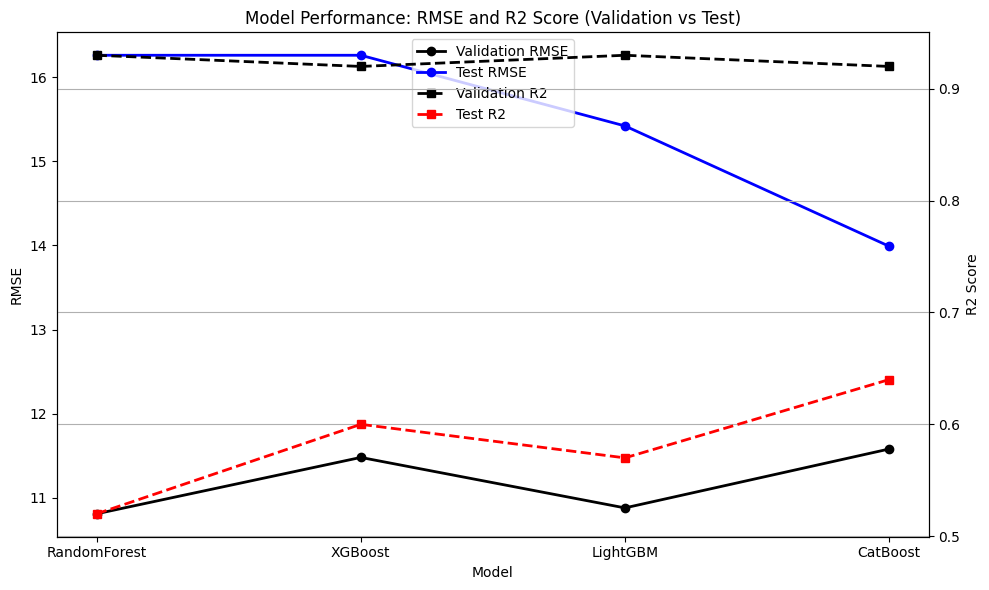

In [60]:
import matplotlib.pyplot as plt

# 모델 이름
models = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
x = range(len(models))

# 검증 성능
val_rmse = [10.81, 11.48, 10.88, 11.58]
val_r2 = [0.93, 0.92, 0.93, 0.92]

# 테스트 성능
test_rmse = [16.26, 16.26, 15.42, 13.99]
test_r2 = [0.52, 0.60, 0.57, 0.64]

# 시각화
fig, ax1 = plt.subplots(figsize=(10, 6))

# RMSE - 왼쪽 y축
ax1.set_xlabel('Model')
ax1.set_ylabel('RMSE', color='black')
ax1.plot(x, val_rmse, marker='o', color='black', label='Validation RMSE', linewidth=2)
ax1.plot(x, test_rmse, marker='o', color='blue', label='Test RMSE', linewidth=2)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(models)

# R2 Score - 오른쪽 y축
ax2 = ax1.twinx()
ax2.set_ylabel('R2 Score', color='black')
ax2.plot(x, val_r2, marker='s', color='black', linestyle='--', label='Validation R2', linewidth=2)
ax2.plot(x, test_r2, marker='s', color='red', linestyle='--', label='Test R2', linewidth=2)
ax2.tick_params(axis='y', labelcolor='black')

# 범례 합치기
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center')

plt.title('Model Performance: RMSE and R2 Score (Validation vs Test)')
plt.grid(True)
plt.tight_layout()
plt.show()

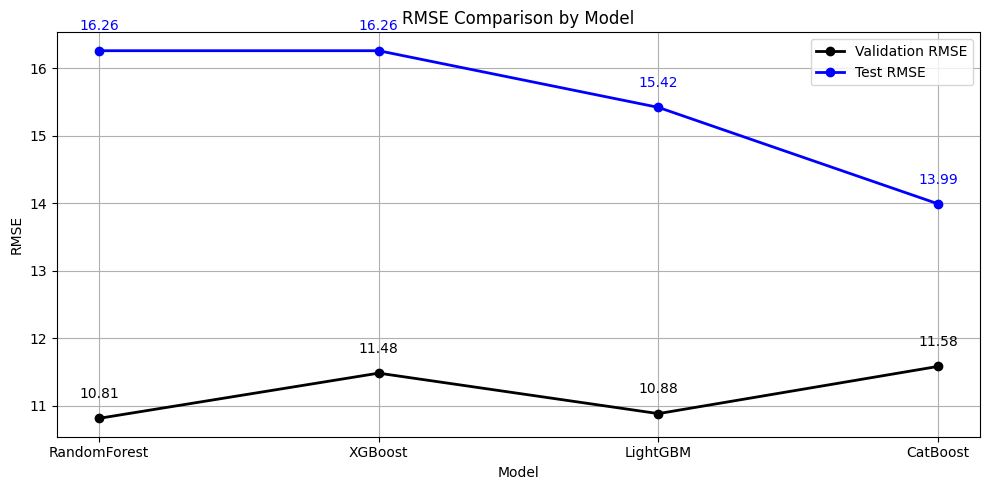

In [62]:
import matplotlib.pyplot as plt

models = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
val_rmse = [10.81, 11.48, 10.88, 11.58]
test_rmse = [16.26, 16.26, 15.42, 13.99]

plt.figure(figsize=(10, 5))
plt.plot(models, val_rmse, marker='o', color='black', label='Validation RMSE', linewidth=2)
plt.plot(models, test_rmse, marker='o', color='blue', label='Test RMSE', linewidth=2)

for i, v in enumerate(val_rmse):
    plt.text(i, v + 0.3, f'{v:.2f}', ha='center', color='black')
for i, v in enumerate(test_rmse):
    plt.text(i, v + 0.3, f'{v:.2f}', ha='center', color='blue')
    
plt.title('RMSE Comparison by Model')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

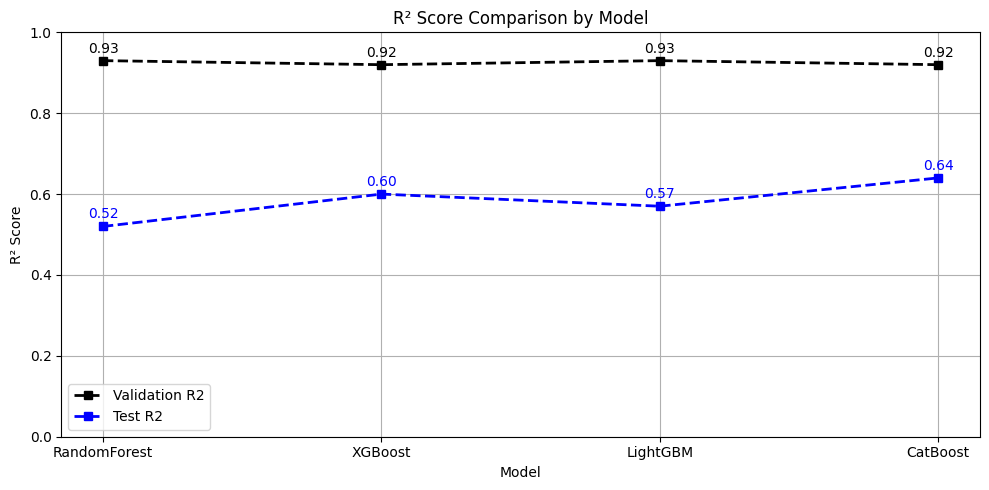

In [64]:
import matplotlib.pyplot as plt

models = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
val_r2 = [0.93, 0.92, 0.93, 0.92]
test_r2 = [0.52, 0.60, 0.57, 0.64]

plt.figure(figsize=(10, 5))
plt.plot(models, val_r2, marker='s', color='black', linestyle='--', label='Validation R2', linewidth=2)
plt.plot(models, test_r2, marker='s', color='blue', linestyle='--', label='Test R2', linewidth=2)

for i, v in enumerate(val_r2):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', color='black')
for i, v in enumerate(test_r2):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', color='blue')
    
plt.title('R² Score Comparison by Model')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

corr = train_x.copy()
corr['target'] = train_y
correlations = corr.corr()['target'].sort_values(ascending=False)
print(correlations)

low_corr_cols = [
    '풍속(m/s)', 'O3', '강수량(mm)', '습도(%)', '중하층운량(10분위)', 
    '전운량(10분위)', '시정(10m)'
]
train_x = train_x.drop(columns=low_corr_cols, errors='ignore')
test_x = test_x.drop(columns=low_corr_cols, errors='ignore')

temp_related = [
    '기온(°C)', '이슬점 온도(°C)', '지면온도(°C)',
    '5cm 지중온도(°C)', '10cm 지중온도(°C)', '20cm 지중온도(°C)',
    '30cm 지중온도(°C)', '증기압(hPa)'
]
train_x = train_x.drop(columns=temp_related, errors='ignore')
test_x = test_x.drop(columns=temp_related, errors='ignore')

train_x['log_PM25'] = np.log1p(train_x['PM25'])
train_y['log_PM25'] = np.log1p(train_y['PM25'])

# [Step 4] 머신러닝 모델에 대해 성능 최적화 진행

* 위 머신러닝 모델들에 대해 성능 최적화를 진행해보세요.

# 아래에 필요한 코드를 작성하고 결과를 확인합니다.
from hyperopt import hp, STATUS_OK
from hyperopt import fmin, tpe, Trials
from sklearn.model_selection import cross_val_score

# 목적 함수 정의
def objective(params):
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    # 교차 검증을 통해 모델 성능 평가
    score = -cross_val_score(model, train_x, train_y, cv=5, scoring='neg_mean_squared_error').mean()
    return {'loss': score, 'status': STATUS_OK}

# 하이퍼파라미터 공간 정의
space = {
    'n_estimators': hp.choice('n_estimators', range(50, 300)),
    'max_depth': hp.choice('max_depth', range(5, 30)),
    'min_samples_split': hp.choice('min_samples_split', range(2, 10)),
    'min_samples_leaf': hp.choice('min_samples_leaf', range(1, 5))
}

# 최적화 실행
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=100, trials=trials)

# 최적의 하이퍼파라미터 출력
print("Best hyperparameters:", best)

# 최적의 하이퍼파라미터로 모델 학습
best_params = {
    'n_estimators': best['n_estimators'],
    'max_depth': best['max_depth'],
    'min_samples_split': best['min_samples_split'],
    'min_samples_leaf': best['min_samples_leaf']
}

rf_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_model.fit(train_x, train_y)

# Test 데이터로 성능을 평가해보세요.
predictions_rf = rf_model.predict(test_x)
mse_value_rf = mse(test_y, predictions_rf)
r2_value_rf = r2_score(test_y, predictions_rf)

print(f'Random Forest Model with Best Hyperparameters MSE: {mse_value_rf}')
print(f'Random Forest Model with Best Hyperparameters R2 Score: {r2_value_rf}')

# # 학습한 모델을 파일로 저장해보세요.
# joblib.dump(rf_model, 'rf_model.pkl')


from hyperopt import hp, STATUS_OK, fmin, tpe, Trials
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error as mse, r2_score
import joblib

# 하이퍼파라미터 후보 리스트
n_estimators_list = list(range(50, 300))
max_depth_list = list(range(5, 30))
min_samples_split_list = list(range(2, 10))
min_samples_leaf_list = list(range(1, 5))

# 하이퍼파라미터 공간 정의
space = {
    'n_estimators': hp.choice('n_estimators', n_estimators_list),
    'max_depth': hp.choice('max_depth', max_depth_list),
    'min_samples_split': hp.choice('min_samples_split', min_samples_split_list),
    'min_samples_leaf': hp.choice('min_samples_leaf', min_samples_leaf_list)
}

# 목적 함수 정의
def objective(params):
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    score = -cross_val_score(model, train_x, train_y, cv=5, scoring='neg_mean_squared_error').mean()
    return {'loss': score, 'status': STATUS_OK}

# 최적화 실행
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=100, trials=trials)

# best는 선택된 인덱스이므로 실제 값을 다시 구성
best_params = {
    'n_estimators': n_estimators_list[best['n_estimators']],
    'max_depth': max_depth_list[best['max_depth']],
    'min_samples_split': min_samples_split_list[best['min_samples_split']],
    'min_samples_leaf': min_samples_leaf_list[best['min_samples_leaf']]
}

print("Best hyperparameters:", best_params)

# 최적 하이퍼파라미터로 모델 학습
rf_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_model.fit(train_x, train_y)

# Test 성능 평가
predictions_rf = rf_model.predict(test_x)
mse_value_rf = mse(test_y, predictions_rf)
r2_value_rf = r2_score(test_y, predictions_rf)

print(f'Best RF Model RMSE: {mse_value_rf ** 0.5:.4f}')
print(f'Best RF Model R2 Score: {r2_value_rf:.4f}')

# 모델 저장
joblib.dump(rf_model, 'rf_model.pkl')


In [66]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 하이퍼파라미터 후보 값 리스트
n_estimators_list = list(range(50, 301, 10))
max_depth_list = list(range(5, 31, 2))
min_samples_split_list = list(range(2, 11))
min_samples_leaf_list = list(range(1, 6))

# 튜닝 공간 정의
space = {
    'n_estimators': hp.choice('n_estimators', n_estimators_list),
    'max_depth': hp.choice('max_depth', max_depth_list),
    'min_samples_split': hp.choice('min_samples_split', min_samples_split_list),
    'min_samples_leaf': hp.choice('min_samples_leaf', min_samples_leaf_list),
}

# 목적 함수 정의
def objective(params):
    model = RandomForestRegressor(
        **params, random_state=42, n_jobs=-1
    )
    score = -cross_val_score(
        model, train_x, train_y.values.ravel(), scoring='neg_mean_squared_error', cv=5
    ).mean()
    return {'loss': score, 'status': STATUS_OK}

# 최적화 수행
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials
)

# best에는 인덱스가 들어 있으므로 실제 값으로 변환
best_params = {
    'n_estimators': n_estimators_list[best['n_estimators']],
    'max_depth': max_depth_list[best['max_depth']],
    'min_samples_split': min_samples_split_list[best['min_samples_split']],
    'min_samples_leaf': min_samples_leaf_list[best['min_samples_leaf']],
}

print("Best Hyperparameters:", best_params)

# 최적 하이퍼파라미터로 모델 학습
rf_best = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_best.fit(train_x, train_y.values.ravel())

# 검증셋 성능 확인
val_preds = rf_best.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
val_r2 = r2_score(y_val, val_preds)
print(f'[Validation] RMSE: {val_rmse:.4f} | R2: {val_r2:.4f}')

# 테스트셋 성능 확인
test_preds = rf_best.predict(test_x)
test_rmse = np.sqrt(mean_squared_error(test_y, test_preds))
test_r2 = r2_score(test_y, test_preds)
print(f'[Test] RMSE: {test_rmse:.4f} | R2: {test_r2:.4f}')


100%|█████████| 50/50 [06:30<00:00,  7.81s/trial, best loss: 1242.0243873540562]
Best Hyperparameters: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1}
[Validation] RMSE: 15.6679 | R2: 0.8580
[Test] RMSE: 16.3353 | R2: 0.5207


- AutoML

In [67]:
class FineDustPredictor:
    def __init__(self, train_x_path, train_y_path, test_x_path, test_y_path):
        self.train_x = pd.read_csv(train_x_path)
        self.train_y = pd.read_csv(train_y_path)
        self.test_x = pd.read_csv(test_x_path)
        self.test_y = pd.read_csv(test_y_path)
        # self.scaler = StandardScaler()
        self.scaler = MinMaxScaler()
        self.tuned_models = []
        self.results = {}
        self.pre_tuning_results = {}

    def normalize_data(self):
        """Normalize the training and testing datasets."""
        self.train_x = pd.DataFrame(self.scaler.fit_transform(self.train_x), columns=self.train_x.columns)
        self.test_x = pd.DataFrame(self.scaler.transform(self.test_x), columns=self.test_x.columns)

    def setup_autoML(self):
        """Set up PyCaret for AutoML and compare models."""
        self.data = pd.concat([self.train_x, self.train_y], axis=1)
        setup(data=self.data, target=self.train_y.columns[0], session_id=42, use_gpu=True)

    def compare_models(self):
        """Compare models based on R2 score and return top 5 models."""
        self.best_models = compare_models(sort='R2', n_select=5)
        return self.best_models

    def evaluate_models(self, models, results_dict):
        """Evaluate the given models on the test dataset and store results."""
        for model in models:
            # Make predictions
            predictions = predict_model(model, data=self.test_x)
            # print(predictions.columns)

            # Use the 'Label' column for predicted values
            pred = predictions['prediction_label']

            # Calculate performance metrics using test_y['PM10_1'] for actual values
            r2 = r2_score(self.test_y['PM10_1'], pred)
            mse = mean_squared_error(self.test_y['PM10_1'], pred)
            model_name = str(model).split('(')[0]  # Extract model name
            results_dict[model_name] = {'R2 Score': r2, 'MSE': mse}

    def stack_models(self):
        """Stack tuned models and evaluate performance."""
        # Prepare base model predictions
        X_meta = []
        y_meta = self.train_y['PM10_1']

        for model in self.tuned_models:
            train_predictions = predict_model(model, data=self.train_x)['prediction_label']
            X_meta.append(train_predictions)

        X_meta = np.array(X_meta).T

        # Split into training and validation sets for stacking
        X_train_meta, X_val_meta, y_train_meta, y_val_meta = train_test_split(X_meta, y_meta, test_size=0.2, random_state=42)

        # Define the stacking model
        stacker = StackingRegressor(
            estimators=[(str(model).split('(')[0], model) for model in self.tuned_models],
            final_estimator=LinearRegression(),
            cv=5
        )

        # Train the stacking model
        stacker.fit(X_train_meta, y_train_meta)

        # Make predictions
        predictions = stacker.predict(X_val_meta)

        # Evaluate the stacking model
        r2 = r2_score(y_val_meta, predictions)
        mse = mean_squared_error(y_val_meta, predictions)

        # Store the stacking results
        self.results['Stacked Model'] = {'R2 Score': r2, 'MSE': mse}
        print(f'Stacked Model - R2 Score: {r2:.4f}, MSE: {mse:.4f}')

    def tune_and_save_models(self):
        """Tune hyperparameters for each of the top models and save them."""
        for model in self.best_models:
            # Save performance metrics before tuning
            self.pre_tuning_results[str(model).split('(')[0]] = {}

            # Evaluate model before tuning
            self.evaluate_models([model], self.pre_tuning_results)

            tuned_model = tune_model(model, optimize='R2')
            self.tuned_models.append(tuned_model)

            # Save original model
            model_name = str(model).split('(')[0]  # Extract model name
            with open(f'./model_{model_name}.pkl', 'wb') as f:
                pickle.dump(model, f)

            # Save tuned model
            with open(f'./tuned_model_{model_name}.pkl', 'wb') as f:
                pickle.dump(tuned_model, f)

            # Evaluate tuned model
            self.evaluate_models([tuned_model], self.results)

        # Call the stacking method after tuning models
        self.stack_models()

    def display_results(self):
        """Display the evaluation results of the models in a formatted way and visualize them."""
        # Prepare data for visualization
        pre_tuning_df = pd.DataFrame.from_dict(self.pre_tuning_results, orient='index').reset_index()
        pre_tuning_df.rename(columns={'index': 'Model Name'}, inplace=True)
        pre_tuning_df['Stage'] = 'Before Tuning'

        post_tuning_df = pd.DataFrame.from_dict(self.results, orient='index').reset_index()
        post_tuning_df.rename(columns={'index': 'Model Name'}, inplace=True)
        post_tuning_df['Stage'] = 'After Tuning'

        # Combine dataframes for visualization
        comparison_df = pd.concat([pre_tuning_df, post_tuning_df], ignore_index=True)

        # Set up the matplotlib figure with larger size and style
        plt.figure(figsize=(16, 8))
        sns.set_style("whitegrid")

        # Create bar plots for R2 Score
        plt.subplot(1, 2, 1)
        r2_plot = sns.barplot(data=comparison_df, x='Model Name', y='R2 Score', hue='Stage', palette='Set2')
        plt.title('R2 Score Comparison', fontsize=16)
        plt.xticks(rotation=45)
        plt.ylabel('R2 Score', fontsize=14)
        plt.xlabel('Model Name', fontsize=14)
        for p in r2_plot.patches:
            r2_plot.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='bottom', fontsize=12)

        # Create bar plots for MSE
        plt.subplot(1, 2, 2)
        mse_plot = sns.barplot(data=comparison_df, x='Model Name', y='MSE', hue='Stage', palette='Set2')
        plt.title('MSE Comparison', fontsize=16)
        plt.xticks(rotation=45)
        plt.ylabel('Mean Squared Error', fontsize=14)
        plt.xlabel('Model Name', fontsize=14)
        for p in mse_plot.patches:
            mse_plot.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='bottom', fontsize=12)

        plt.tight_layout()
        plt.show()

        # Print results in text format with improved formatting
        print("\nModel Evaluation Results Before Tuning:")
        print(f"{'Model Name':<30} {'R2 Score':<15} {'MSE':<15}")
        print("-" * 60)
        for model_name, metrics in self.pre_tuning_results.items():
            print(f"{model_name:<30} {metrics['R2 Score']:<15.4f} {metrics['MSE']:<15.4f}")

        print("\nModel Evaluation Results After Tuning:")
        print(f"{'Model Name':<30} {'R2 Score':<15} {'MSE':<15}")
        print("-" * 60)
        for model_name, metrics in self.results.items():
            print(f"{model_name:<30} {metrics['R2 Score']:<15.4f} {metrics['MSE']:<15.4f}")


In [74]:
predictor = FineDustPredictor(
    train_x_path='train_x1.csv',
    train_y_path='train_y1.csv',
    test_x_path='test_x1.csv',
    test_y_path='test_y1.csv'
)

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

predictor.normalize_data()
predictor.setup_autoML()
best_models = predictor.compare_models()
print("Top 5 Models based on R2 Score:")
print(best_models)

ValueError: could not convert string to float: '2021-10-02 00:00'

In [78]:
predictor.tune_and_save_models()

AttributeError: 'FineDustPredictor' object has no attribute 'best_models'

In [ ]:
predictor.stack_models()

In [ ]:
predictor.display_results()

- 단순 모델 돌린 것의 기본 평균내는 앙상블 진행

In [ ]:
# train_y와 test_y를 1차원 배열로 변환
train_y = train_y.ravel()
test_y = test_y.ravel()

# train_y = train_y.values.ravel()
# test_y = test_y.values.ravel()

model_num = 4

# 각 모델 학습
# knn_model = KNeighborsRegressor(n_neighbors=5).fit(train_x, train_y)
linear_model = LinearRegression().fit(train_x, train_y)
ridge_model = Ridge(alpha=1.0, random_state=42).fit(train_x, train_y)
rf_model = RFR(n_estimators=100, random_state=42).fit(train_x, train_y)
gbm_model = GBR(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42).fit(train_x, train_y)
cat_model= CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=False, random_seed=42).fit(train_x, train_y)

# 각 모델의 예측
# predictions_knn = knn_model.predict(test_x)
predictions_linear = linear_model.predict(test_x)
predictions_ridge = ridge_model.predict(test_x)
predictions_rf = rf_model.predict(test_x)
predictions_gbm = gbm_model.predict(test_x)
predictions_cat = cat_model.predict(test_x)


# 앙상블: 각 모델의 예측 평균
ensemble_predictions = (predictions_cat + predictions_linear + predictions_ridge + predictions_rf ) / model_num

# 앙상블 모델 성능 평가
mse_value_ensemble = mse(test_y, ensemble_predictions)
r2_value_ensemble = r2_score(test_y, ensemble_predictions)

print(f'Ensemble Model MSE: {mse_value_ensemble}')
print(f'Ensemble Model R2 Score: {r2_value_ensemble}')

# 각 모델 저장
# joblib.dump(knn_model, 'knn_model.pkl')
# joblib.dump(linear_model, 'linear_model.pkl')
# joblib.dump(ridge_model, 'ridge_model.pkl')
# joblib.dump(rf_model, 'rf_model.pkl')
# joblib.dump(gbm_model, 'gbm_model.pkl')

- Stacking Ensemble

In [80]:
# train_y와 test_y를 1차원 배열로 변환
train_y = train_y.ravel()
test_y = test_y.ravel()

# 베이스 모델 정의
base_models = [
    ('linear', LinearRegression()),
    ('ridge', Ridge(alpha=1.0, random_state=42)),
    ('rf', RFR(n_estimators=100, random_state=42)),
    ('cat', CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=False, random_seed=42))
    # ('gbm', GBR(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
]

# 메타 모델 정의
meta_model = LinearRegression()

# 스태킹 앙상블 모델 정의
stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model)

# 스태킹 모델 학습
stacking_model.fit(train_x, train_y)

# 스태킹 모델 예측
ensemble_predictions = stacking_model.predict(test_x)

# 스태킹 모델 성능 평가
mse_value_ensemble = mse(test_y, ensemble_predictions)
r2_value_ensemble = r2_score(test_y, ensemble_predictions)

print(f'Stacking Ensemble Model MSE: {mse_value_ensemble}')
print(f'Stacking Ensemble Model R2 Score: {r2_value_ensemble}')

# 스태킹 모델 저장
# joblib.dump(stacking_model, 'stacking_model.pkl')

AttributeError: 'DataFrame' object has no attribute 'ravel'

# [Step 5] 시계열 모델 ARIMA, SARIMA. RNN/LSTM 모델 고려 할수 ~

* 시간이 된다면 위의 언급된 모델을 만들고 성능평가해 보세요.

In [82]:
import pandas as pd
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score

# 최적의 SARIMA 파라미터 찾기
# 계절성을 반영하여 seasonal=True, m=12 (12개월 주기 예시)로 설정
sarima_model = auto_arima(y_train, seasonal=True, m=12, trace=True,
                          error_action='ignore', suppress_warnings=True,
                          stepwise=True)

# 최적화된 파라미터 확인
print(f'Optimal parameters: {sarima_model.order}, Seasonal order: {sarima_model.seasonal_order}')

# SARIMA 모델을 최적화된 파라미터로 재학습
model = SARIMAX(y_train, order=sarima_model.order,
                seasonal_order=sarima_model.seasonal_order)
sarima_fitted = model.fit(disp=False)

# 검증 데이터에 대한 예측 수행
y_pred = sarima_fitted.predict(start=len(y_train), end=len(y_train) + len(y_val) - 1, dynamic=False)

# 성능 평가 (MSE와 R2 Score)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f'MSE on Validation Set: {mse}')
print(f'R2 Score on Validation Set: {r2}')

ModuleNotFoundError: No module named 'pmdarima'

# 시계열 모델 

In [51]:
# 회귀 모델용
train_x = pd.read_csv('train_x2.csv', encoding='utf-8-sig')
train_y = pd.read_csv('train_y2.csv', encoding='utf-8-sig')

test_x  = pd.read_csv('test_x2.csv',  encoding='utf-8-sig')
test_y = pd.read_csv('test_y2.csv',  encoding='utf-8-sig')

In [53]:
# 학습/검증 분할
split_idx = int(len(train_y) * 0.8)
y_train = train_y[:split_idx]
y_val = train_y[split_idx:]

## ARIMA

In [55]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# ARIMA 모델 정의 및 학습
arima_model = ARIMA(y_train, order=(2, 1, 2))  # (p,d,q) 값은 상황에 따라 조정
arima_fitted = arima_model.fit()

# 예측
y_pred_arima = arima_fitted.forecast(steps=len(y_val))

# 성능 평가
rmse_arima = np.sqrt(mean_squared_error(y_val, y_pred_arima))
r2_arima = r2_score(y_val, y_pred_arima)

print(f' [ARIMA] rmse Set: {rmse_arima:.4f}')
print(f' [ARIMA] r2 Set: {r2_arima:.4f}')

 [ARIMA] rmse Set: 12.4526
 [ARIMA] r2 Set: -0.4685


## SARIMA

In [57]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score

# 이미 준비된 y_train, y_val 사용한다고 가정
# 예시: train_y = pd.read_csv('train_y2.csv')
# split_idx = int(len(train_y) * 0.8)
# y_train = train_y[:split_idx]
# y_val = train_y[split_idx:]

# SARIMA 최적 파라미터 탐색
sarima_model = auto_arima(y_train, seasonal=True, m=12, trace=True,
                          error_action='ignore', suppress_warnings=True, stepwise=True)

print(f'Optimal parameters: {sarima_model.order}, Seasonal order: {sarima_model.seasonal_order}')

# 모델 학습
model = SARIMAX(y_train, order=sarima_model.order,
                seasonal_order=sarima_model.seasonal_order)
sarima_fitted = model.fit(disp=False)

# 예측 (y_val 길이만큼)
y_pred = sarima_fitted.predict(start=len(y_train), end=len(y_train) + len(y_val) - 1)

# 평가
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f'✅ RMSE on Validation Set: {rmse:.4f}')
print(f'✅ R2 Score on Validation Set: {r2:.4f}')

AttributeError: module 'numpy.linalg._umath_linalg' has no attribute '_ilp64'

## LSTM

In [59]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, r2_score

# 정규화
scaler = MinMaxScaler()
scaled = scaler.fit_transform(y_series.values.reshape(-1, 1))

# 분할
split_index = int(len(scaled) * 0.8)
scaled_train, scaled_val = scaled[:split_index], scaled[split_index:]

# 시퀀스 생성
timesteps = 10
X_train, y_train_seq = [], []
for i in range(timesteps, len(scaled_train)):
    X_train.append(scaled_train[i - timesteps:i])
    y_train_seq.append(scaled_train[i])
X_train, y_train_seq = np.array(X_train), np.array(y_train_seq)

X_val = []
for i in range(len(scaled_val) - timesteps):
    X_val.append(scaled_val[i:i+timesteps])
X_val = np.array(X_val)
y_val_actual = scaler.inverse_transform(scaled_val[timesteps:])

# 모델 정의
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(timesteps, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# 학습
model.fit(X_train, y_train_seq, epochs=20, batch_size=32, verbose=0)

# 예측
y_pred_scaled = model.predict(X_val)
y_pred_lstm = scaler.inverse_transform(y_pred_scaled)

# 성능 평가
rmse_lstm = np.sqrt(mean_squared_error(y_val_actual, y_pred_lstm))
r2_lstm = r2_score(y_val_actual, y_pred_lstm)

print(f'✅ [LSTM] RMSE on Validation Set: {rmse_lstm:.4f}')
print(f'✅ [LSTM] R2 Score on Validation Set: {r2_lstm:.4f}')


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/yuserih/env39/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/7j/f120srpx2wn9pv0lldg7j2240000gn/T/ipykernel_17840/2174532067.py", line 3, in <module>
    from tensorflow.keras.models import Sequential
  File "/Users/yuserih/env39/lib/python3.9/site-packages/tensorflow/__init__.py", line 49, in <module>
    from tensorflow._api.v2 import __internal__
  File "/Users/yuserih/env39/lib/python3.9/site-packages/tensorflow/_api/v2/__internal__/__init__.py", line 8, in <module>
    from tensorflow._api.v2.__internal__ import autograph
  File "/Users/yuserih/env39/lib/python3.9/site-packages/tensorflow/_api/v2/__internal__/autograph/__init__.py", line 8, in <module>
    from tensorflow.python.autograph.core.ag_ctx import control_status_ctx # line: 34
  File "/Users/yuserih/env39/lib/python3.9/site-packages/tensorflow/python/autograph/

In [3]:
pip install tensorflow

  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 MB 144.5 kB/s eta 0:00:0000:0100:18
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 121.7 kB/s eta 0:00:00a 0:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 93.8 kB/s eta 0:00:0000:0100:04m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 138.4 kB/s eta 0:00:0000:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 176.3 kB/s eta 0:00:0000:0100:07
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.6/667.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 179.6 kB/s eta 0:00:0000:0100:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 178.6 kB/s eta 0:00:00a 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 111.1 kB/s eta 0:00:0000:0100:04
Using cached wheel-0.45.1-py3-none-any.whl (72 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.1
    Uninstalling nump